### Modeling the early events in signaling by the epidermal growth factor receptor (EGFR), [Blinov 2006](https://www.sciencedirect.com/science/article/abs/pii/S0303264705001231/)


### Study of EGFR Clustering Dynamics
### Goal: Investigating the steady-state cluster distribution of the Epidermal Growth Factor Receptor (EGFR) based on the Blinov (2006) model.

In [2]:
import pandas as pd
import os
# 1. Load the data from the folder we found earlier
# (Make sure this path matches your EGFR results folder)
data_path = "test_dataset/Tutorial_Nephrin_Nck_NWASP/pyStat/SteadyState_distribution.csv"
data = pd.read_csv(data_path)

# 2. Now run your "Meaningful Analysis"
weighted_avg = (data['Cluster size'] * data['foTM']).sum()
print(f"Mean Cluster Size (Weighted): {weighted_avg:.3f} molecules")

max_cluster = data['Cluster size'].max()
print(f"Largest Signaling Platform Size: {max_cluster} molecules")

Mean Cluster Size (Weighted): 2.528 molecules
Largest Signaling Platform Size: 23 molecules


Success! Data loaded from pyStat.
   Cluster size  frequency      foTM
0             1   0.766644  0.518182
1             2   0.131944  0.178364
2             3   0.046806  0.094909
3             4   0.023134  0.062545
4             5   0.010625  0.035909


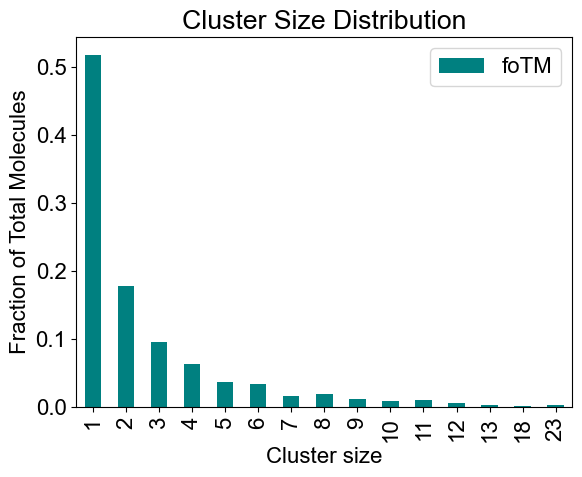

In [34]:

# 1. Path to the automatically generated pyStat folder
results_path = "test_dataset/Tutorial_Nephrin_Nck_NWASP/pyStat/SteadyState_distribution.csv"

# 2. Load the data
if os.path.exists(results_path):
    data = pd.read_csv(results_path)
    print("Success! Data loaded from pyStat.")
    print(data.head())
else:
    print("File not found. Please ensure process_speciesfiles() ran successfully.")

# 3. Quick Plot (Optional)
import matplotlib.pyplot as plt
data.plot(x='Cluster size', y='foTM', kind='bar', color='teal')
plt.ylabel('Fraction of Total Molecules')
plt.title('Cluster Size Distribution')
plt.show()


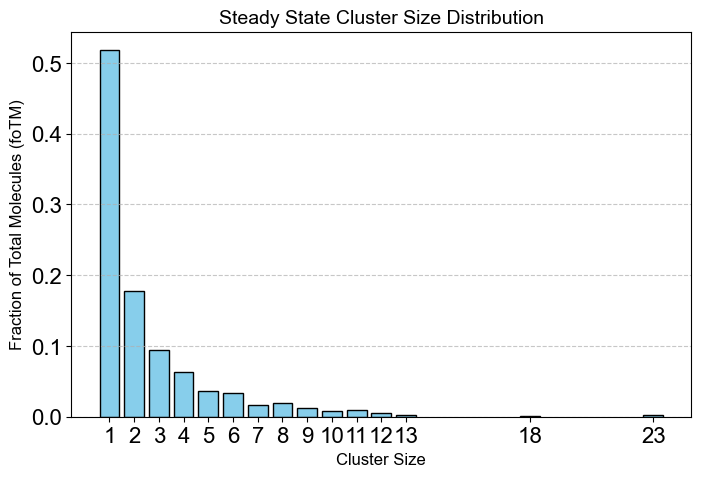

In [35]:
import matplotlib.pyplot as plt

# Plotting Cluster Size vs. Fraction of Total Molecules (foTM)
plt.figure(figsize=(8, 5))
plt.bar(data['Cluster size'], data['foTM'], color='skyblue', edgecolor='black')

plt.xlabel('Cluster Size', fontsize=12)
plt.ylabel('Fraction of Total Molecules (foTM)', fontsize=12)
plt.title('Steady State Cluster Size Distribution', fontsize=14)
plt.xticks(data['Cluster size']) # Shows every size on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [36]:
import os
print(os.getcwd())  # This shows your "Current Working Directory"
print(os.listdir()) # This lists all files/folders in that directory


C:\Users\pvenu\Documents\MolClustPy_local
['.git', '.ipynb_checkpoints', 'DataViz_NFsim.py', 'EGFR_model.ipynb', 'HelperFunctions.py', 'LICENSE.MD', 'molclustpy_package', 'MultiRun_BNG.py', 'Nephrin_Nck_NWASP_high_concentration.ipynb', 'NFsim_data_analyzer.py', 'README.md', 'test_dataset', 'TLBR_model.ipynb', 'Tutorial_Nephrin_Nck_NWASP.ipynb', '__pycache__']


In [37]:
# Check for any new attributes like 'dist_stat', 'MCL_stat', or 'cluster_distribution'
print("Current attributes:", [attr for attr in dir(analyzer) if not attr.startswith('__')])


Current attributes: ['collect_clusters', 'flatten_', 'getMolecularBondCount', 'getOutpath', 'path', 'process_gdatfiles', 'process_speciesfiles', 'writeBFdata', 'writeComposition', 'writeCountData', 'writeDistribution', 'writeMCLdata']


In [38]:
import pandas as pd

# The analyzer saves the count data as 'Mean_Observable_Counts.txt'
# Note: These are usually tab-separated (\t)
data_path = "test_dataset/Tutorial_Nephrin_Nck_NWASP/pyStat/Mean_Observable_Counts.txt"

data = pd.read_csv(data_path, sep='\t')

print("CSV (Observable Counts) Loaded Successfully!")
print(data.head())


CSV (Observable Counts) Loaded Successfully!
                                              # time  tot_Nck  free_Nck  \
0  0.000000e+00 3.000000e+02 3.000000e+02 1.50000...      NaN       NaN   
1  1.000000e-03 3.000500e+02 1.870000e+02 1.50050...      NaN       NaN   
2  2.000000e-03 3.001500e+02 1.614500e+02 1.50150...      NaN       NaN   
3  3.000000e-03 3.003000e+02 1.560000e+02 1.50300...      NaN       NaN   
4  4.000000e-03 3.005000e+02 1.559500e+02 1.50450...      NaN       NaN   

   tot_NWASP  free_NWASP  tot_Nephrin  free_Nephrin  fully_bound_Nephrin  \
0        NaN         NaN          NaN           NaN                  NaN   
1        NaN         NaN          NaN           NaN                  NaN   
2        NaN         NaN          NaN           NaN                  NaN   
3        NaN         NaN          NaN           NaN                  NaN   
4        NaN         NaN          NaN           NaN                  NaN   

   fully_bound_Nck  fully_bound_NWASP  cluster_

### This model has multi-molecular complex as initial conditions

In [40]:
# Change this line to include the folder path
bng_file = "test_dataset/EGFR_model.bngl" 

# Now run the trials
simObj = BNG_multiTrials(bng_file, t_end=20, steps=20, numRuns=20)
print(simObj)
simObj.runTrials(delSim=False)



***** // ***** 
Class : BNG_multiTrials
File Path : test_dataset/EGFR_model.bngl

t_end : 20 seconds 	 output_steps : 20
Number of runs: 20

Molecules: ['Grb2', 'Shc', 'Sos', 'egf', 'egfr']
Number of binding sites: [2, 2, 1, 1, 4]
Species Counts: [120.0, 10.0, 27.0, 13.0, 180.0, 49.0]

*** WARNING ***
Number of species is different than number of molecular types!
In case you have multi-molecular species as your initial condition, please provide total counts of each molecular types for subsequent analysis!

NFsim progress : [****************************************] 100%
Execution time : 13.9774 seconds


In [ ]:
# analyze data across multiple trials
outpath = simObj.getOutPath()
molecules, numSite, counts, _ = simObj.getMolecules()
nfsObj = NFSim_output_analyzer(outpath)
nfsObj.process_gdatfiles()
#nfsObj.process_speciesfiles(molecules, counts=counts, valency=numSite) # will give an error
nfsObj.process_speciesfiles(molecules, counts=[59,27,62,120,180], valency=numSite)

### Visualization

In [ ]:
plt.hist(data["ClusterSize"], bins=20)
plt.title("Cluster size distribution")
plt.xlabel("Cluster size")
plt.ylabel("Frequency")
plt.show()

In [ ]:
plotTimeCourse(outpath, obsList=[1,5,11])

### 2. Plot system level quantities

In [ ]:
# 2A: Cluster size distribution (ACO: Average Cluster Occupancy)
plotClusterDist(outpath)
# You can plot a binned distribution by providing cluster size ranges
plotClusterDist(outpath, sizeRange=[1,10])

In [ ]:
# 2B: Number of bonds per molecule
plotBondsPerMolecule(outpath)
# 2C: Bound fraction distribution
plotBoundFraction(outpath)

### 3. Plot molecule specific quantities

In [ ]:
# 3A. Average composition of indivual clusters. 
# Default is all the clusters present in the system. As before, adjust width and transparency (alpha) for visual clarity.
plotClusterComposition(outpath, specialClusters=[], width=0.15, alpha=0.5)

# You can look at the composition of a set of clusters (specialClusters) also
plotClusterComposition(outpath, specialClusters=[4, 6, 7], width=0.15, alpha=0.5)

In [ ]:
# 3B. Bondcount distribution of each molecular type 
# You may provide a subset of molecules also
plotBondCounts(outpath, molecules=['egfr'])